In [4]:
#cell 0: import dataset from kaggle
import kagglehub

path = kagglehub.dataset_download("manmandes/malimg")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\KhaiNT\.cache\kagglehub\datasets\manmandes\malimg\versions\1


In [5]:
#cell 1: import libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
  

In [6]:
#cell 2: define dataset directories and classes
import pandas as pd

train_dir = os.path.join(path, "malimg_dataset/train")
val_dir = os.path.join(path, "malimg_dataset/val")
test_dir = os.path.join(path, "malimg_dataset/test")  

classes = sorted(os.listdir(train_dir))

# Count samples in each class for each dataset
data = []
for class_name in classes:
    train_count = len(os.listdir(os.path.join(train_dir, class_name)))
    val_count = len(os.listdir(os.path.join(val_dir, class_name)))
    test_count = len(os.listdir(os.path.join(test_dir, class_name)))
    total_count = train_count + val_count + test_count
    
    data.append({
        'Class': class_name,
        'Train': train_count,
        'Validation': val_count,
        'Test': test_count,
        'Total': total_count
    })

# Create DataFrame
df = pd.DataFrame(data)

# Calculate totals
total_row = pd.DataFrame([{
    'Class': 'TOTAL',
    'Train': df['Train'].sum(),
    'Validation': df['Validation'].sum(),
    'Test': df['Test'].sum(),
    'Total': df['Total'].sum()
}])

df = pd.concat([df, total_row], ignore_index=True)

print(df.to_string(index=False))

         Class  Train  Validation  Test  Total
     Adialer.C     97          12    13    122
     Agent.FYI     92          11    13    116
     Allaple.A   2359         294   296   2949
     Allaple.L   1272         159   160   1591
 Alueron.gen!J    158          19    21    198
     Autorun.K     84          10    12    106
       C2LOP.P    116          14    16    146
   C2LOP.gen!g    160          20    20    200
Dialplatform.B    141          17    19    177
     Dontovo.A    129          16    17    162
      Fakerean    304          38    39    381
 Instantaccess    344          43    44    431
    Lolyda.AA1    170          21    22    213
    Lolyda.AA2    147          18    19    184
    Lolyda.AA3     98          12    13    123
     Lolyda.AT    127          15    17    159
   Malex.gen!J    108          13    15    136
 Obfuscator.AD    113          14    15    142
      Rbot!gen    126          15    17    158
    Skintrim.N     64           8     8     80
 Swizzor.gen!

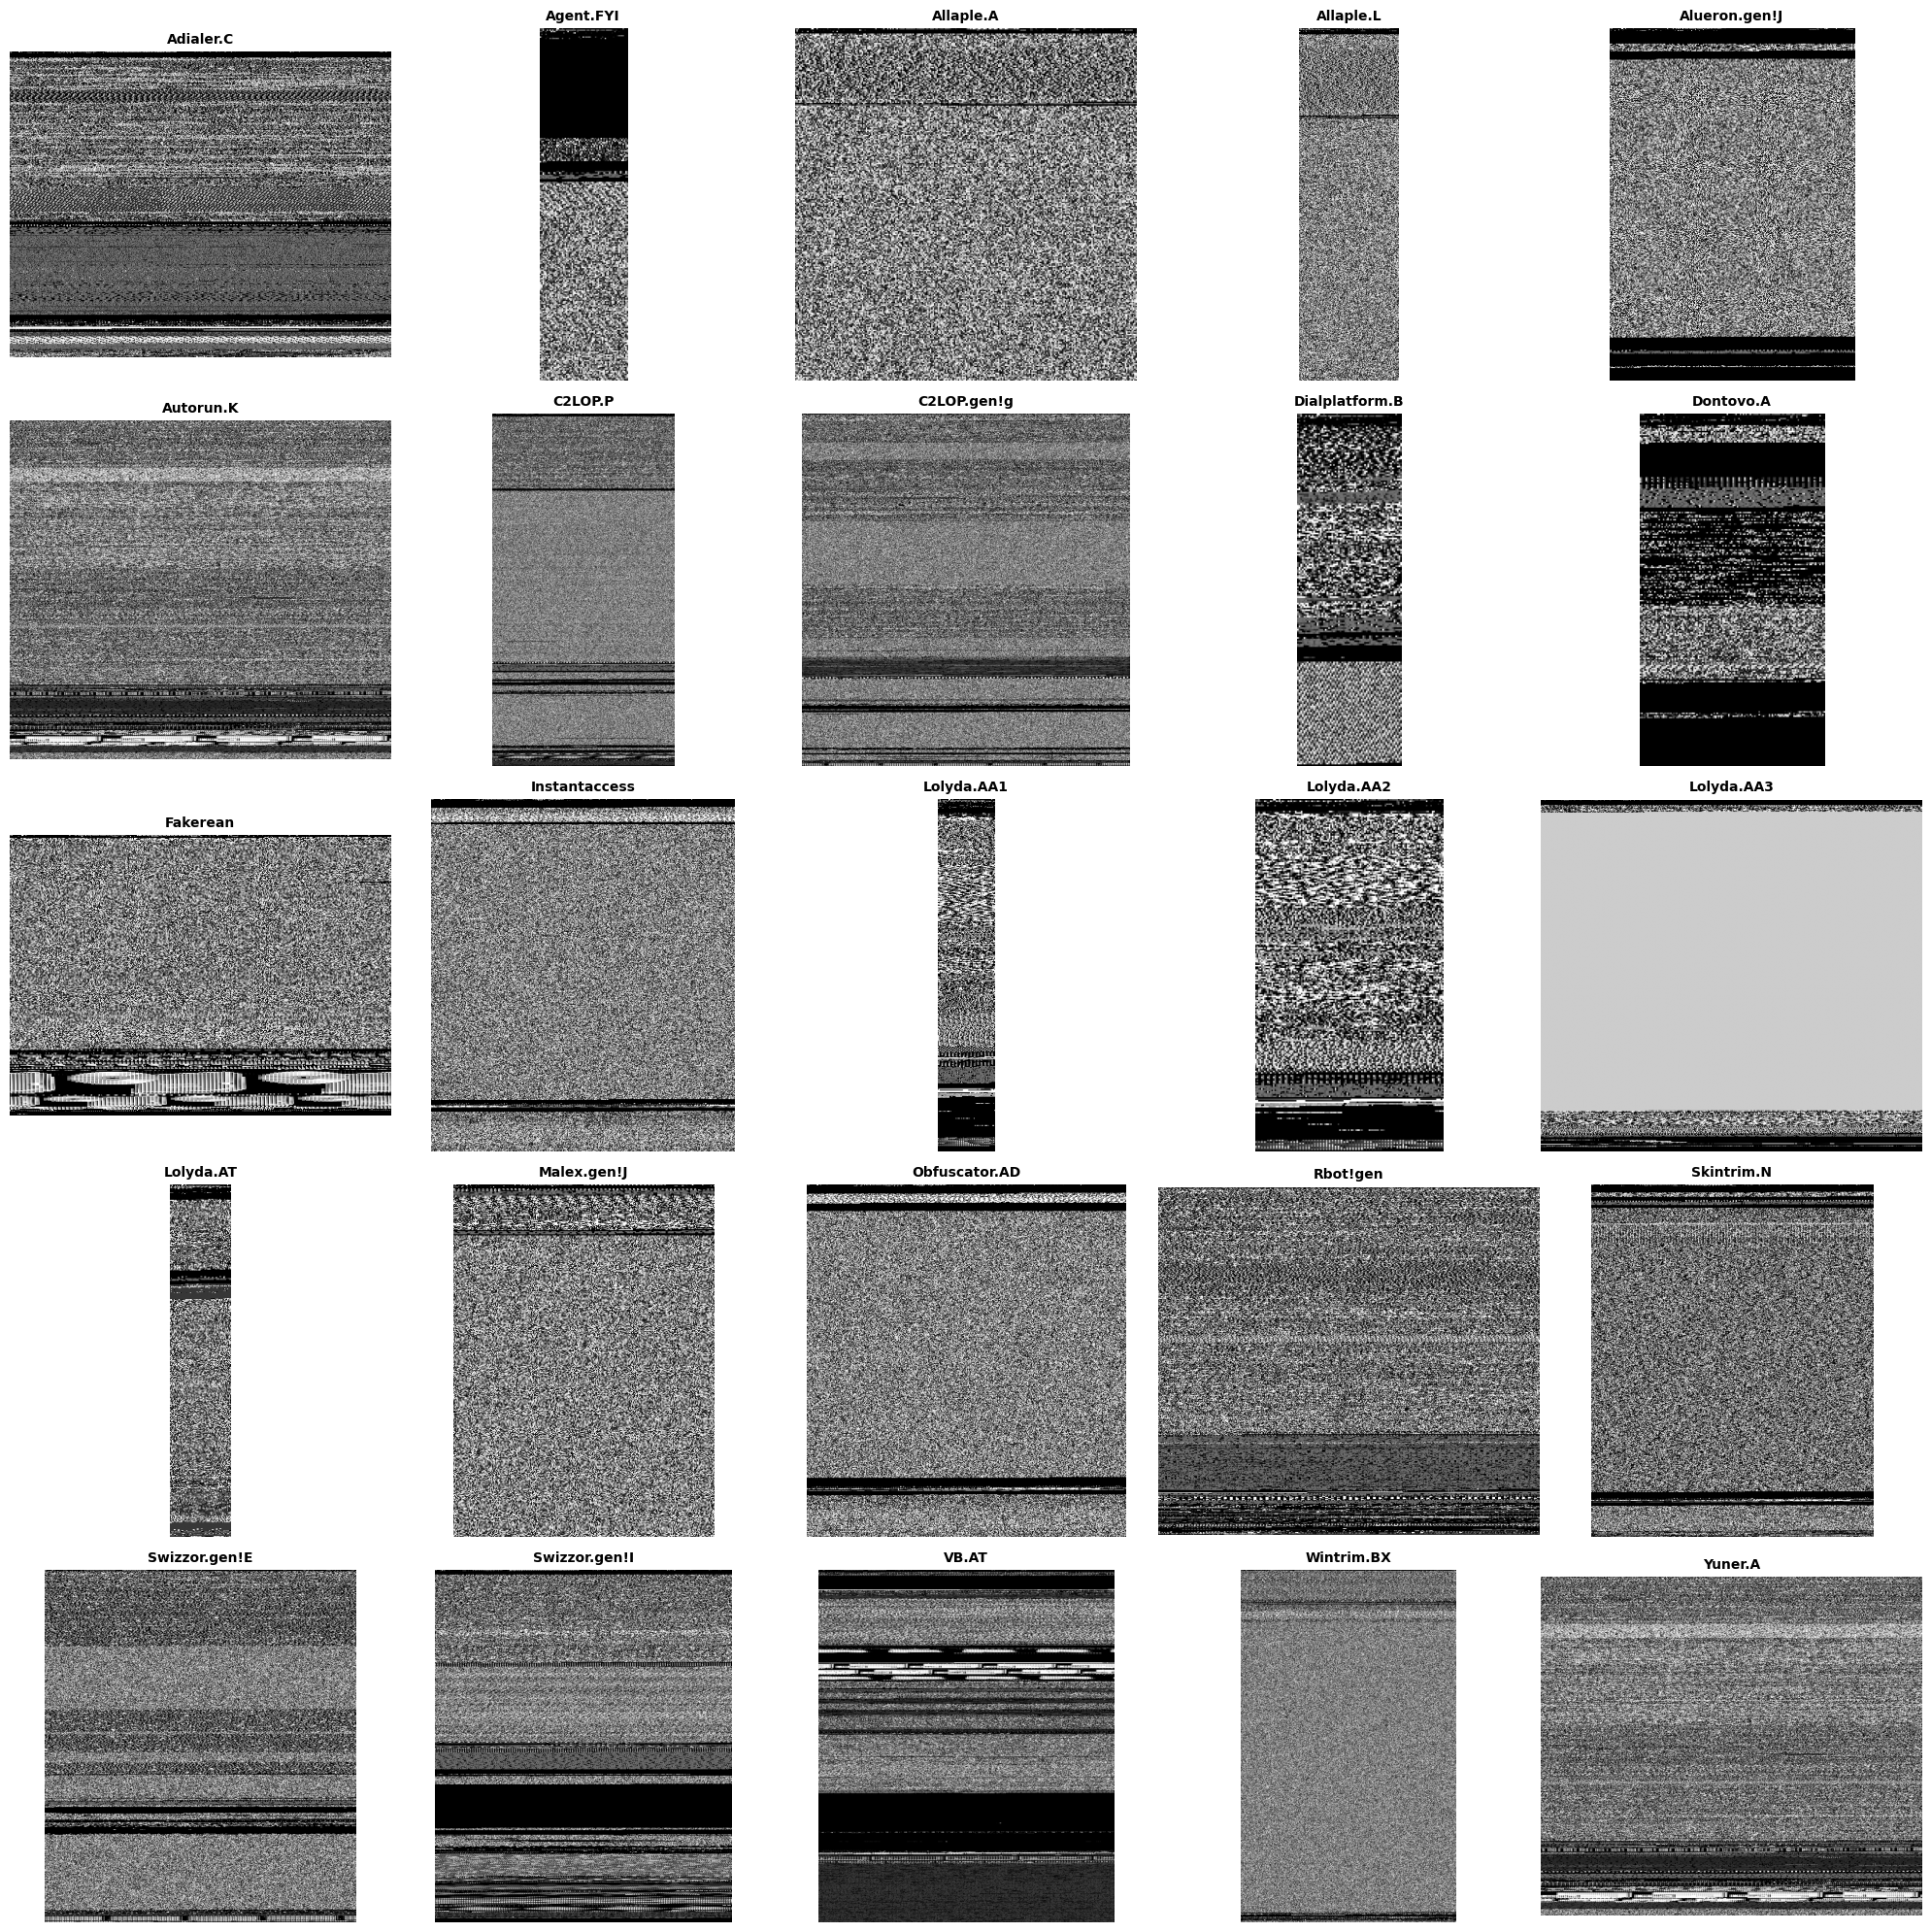


Displayed 25 malware classes


In [7]:
# Display one example image from each class
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get class names
class_names = sorted(os.listdir(train_dir))

# Calculate grid size (5 columns)
n_classes = len(class_names)
n_cols = 5
n_rows = (n_classes + n_cols - 1) // n_cols  # Ceiling division

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

# Display one image from each class
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    
    if images:
        # Get the first image
        img_path = os.path.join(class_path, images[0])
        img = mpimg.imread(img_path)
        
        # Display image
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f'{class_name}', fontsize=10, fontweight='bold')
        axes[idx].axis('off')

# Hide any unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f'\nDisplayed {n_classes} malware classes')

Pixel value range after rescaling: [0.000, 1.000]


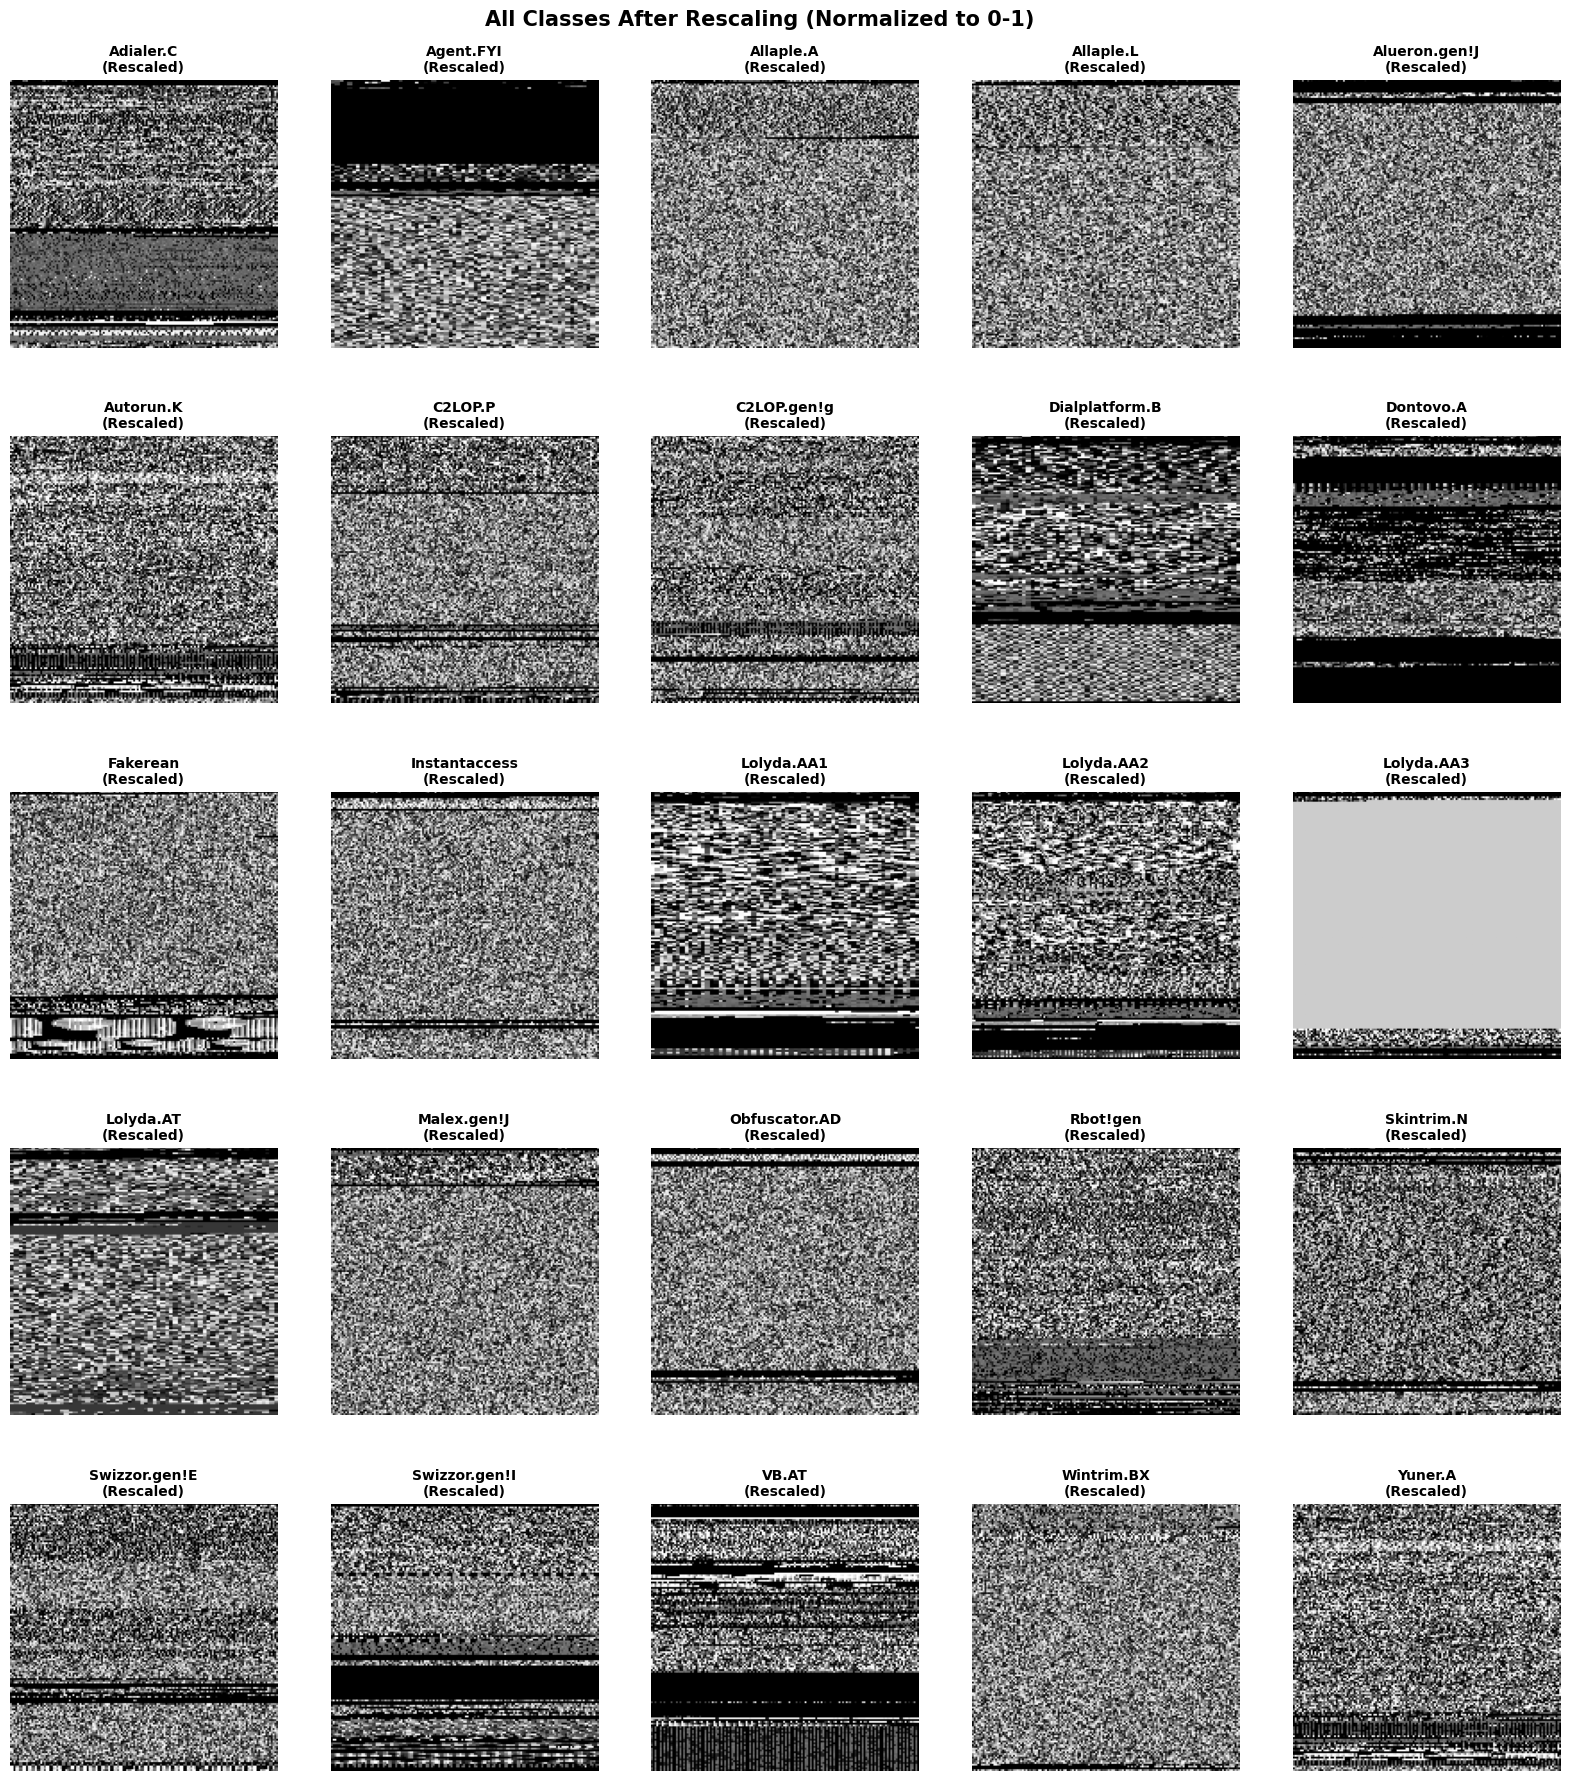


Displayed 25 malware classes after rescaling


In [18]:
#cell 3: data augmentation and preprocessing
train_datagen = ImageDataGenerator(rescale=1/255)
val_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

# Display one example from each class after rescaling
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Get class names
class_names = sorted(os.listdir(train_dir))

# Calculate grid size (5 columns)
n_classes = len(class_names)
n_cols = 5
n_rows = (n_classes + n_cols - 1) // n_cols  # Ceiling division

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

# Display one preprocessed image from each class
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    
    if images:
        # Get the first image
        img_path = os.path.join(class_path, images[0])
        
        # Load and preprocess image (resize + rescale)
        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img)
        img_rescaled = img_array / 255.0  # Apply rescaling
        
        # Display image
        axes[idx].imshow(img_rescaled, cmap='gray')
        axes[idx].set_title(f'{class_name}\n(Rescaled)', fontsize=10, fontweight='bold')
        axes[idx].axis('off')
        
        # Show pixel value range for first class
        if idx == 0:
            print(f"Pixel value range after rescaling: [{img_rescaled.min():.3f}, {img_rescaled.max():.3f}]")

# Hide any unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('All Classes After Rescaling (Normalized to 0-1)', 
             fontsize=15, fontweight='bold', y=0.998)
plt.subplots_adjust(top=0.97)
plt.show()

print(f'\nDisplayed {n_classes} malware classes after rescaling')

In [21]:
#cell 4: create data generators for training dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)
print("Training data generator created.")

Found 7459 images belonging to 25 classes.
Training data generator created.


In [22]:
#cell 5: create data generators for validation dataset
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)
print("Validation data generator created.")

Found 923 images belonging to 25 classes.
Validation data generator created.


In [23]:
#cell 6: create data generators for test dataset
test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)
print("Test data generator created.")

Found 957 images belonging to 25 classes.
Test data generator created.


Class weights: {0: 3.075876288659794, 1: 3.2430434782608697, 2: 0.12647732089868588, 3: 0.23455974842767296, 4: 1.8883544303797468, 5: 3.551904761904762, 6: 2.5720689655172415, 7: 1.86475, 8: 2.116028368794326, 9: 2.3128682170542634, 10: 0.9814473684210526, 11: 0.8673255813953489, 12: 1.7550588235294118, 13: 2.0296598639455783, 14: 3.044489795918367, 15: 2.349291338582677, 16: 2.7625925925925925, 17: 2.640353982300885, 18: 2.367936507936508, 19: 4.661875, 20: 2.9250980392156865, 21: 2.8415238095238093, 22: 0.9152147239263804, 23: 3.874805194805195, 24: 0.4661875}


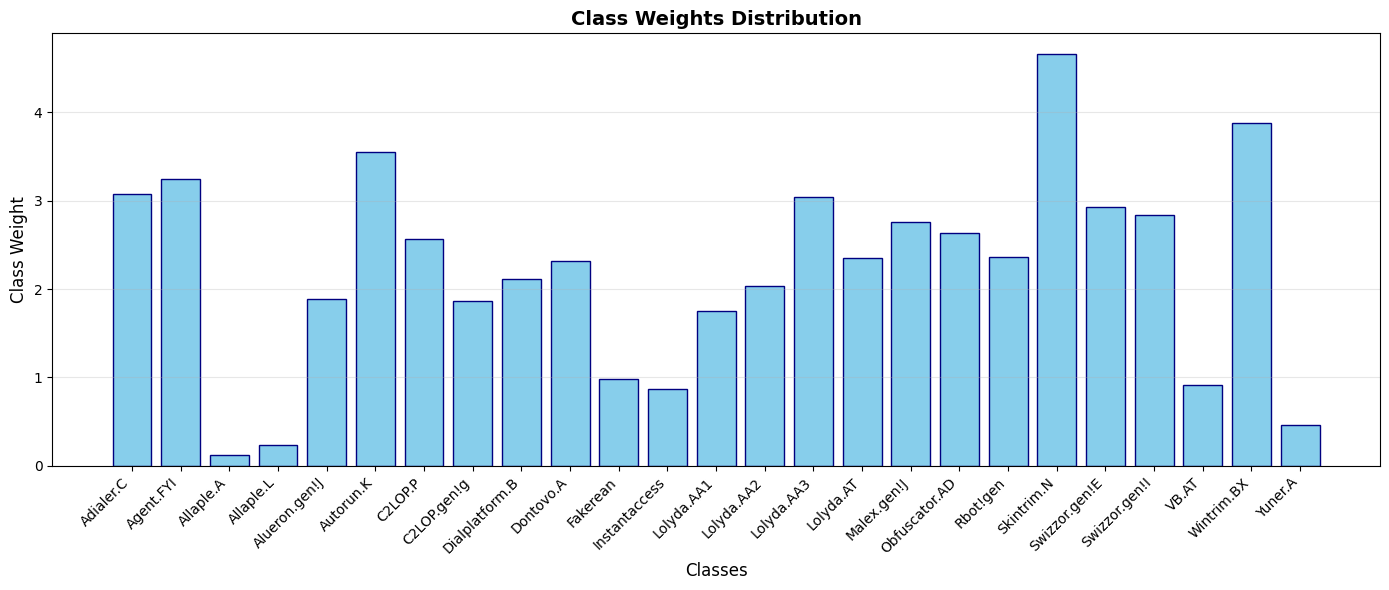

In [25]:
#cell 7: compute class weights to handle class imbalance
import matplotlib.pyplot as plt

class_weights = class_weight.compute_class_weight('balanced', 
                                                  classes=np.unique(train_generator.classes), 
                                                  y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict) 

# Create bar chart for class weights
class_names = list(train_generator.class_indices.keys())
weights = [class_weight_dict[i] for i in range(len(class_names))]

plt.figure(figsize=(14, 6))
plt.bar(range(len(class_names)), weights, color='skyblue', edgecolor='navy')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Class Weight', fontsize=12)
plt.title('Class Weights Distribution', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
#cell 8: Load the pre-trained MobileNetV2 model (without the top layer)
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)
print("Pre-trained MobileNetV2 model loaded.")

C:\Users\KhaiNT\AppData\Local\Temp\ipykernel_22832\357639447.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Pre-trained MobileNetV2 model loaded.


In [ ]:
#cell 9: Freeze the layers of MobileNetV2
for layer in base_model.layers:
    layer.trainable = False
print("Base model layers frozen.")

Base model layers frozen.


In [30]:
#cell 10: Add a GlobalAveragePooling layer to flatten the output of the convolutional base
x = GlobalAveragePooling2D()(base_model.output)
print("GlobalAveragePooling2D layer added.")

GlobalAveragePooling2D layer added.


In [32]:
#cell 11: Output layer with 25 classes
output = Dense(25, activation='softmax')(x)
print("Output layer added.")

Output layer added.


In [34]:

# Create the complete model
MobileNet_model = Model(
    inputs=base_model.input, 
    outputs=output)

In [ ]:
# Train the model
# Compile the model
MobileNet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

history = MobileNet_model.fit(
    train_generator,
    epochs=10,  
    validation_data=val_generator,
    class_weight=class_weight_dict, 
)

# Save training history to CSV
import pandas as pd
from datetime import datetime

# Create a DataFrame from history
history_df = pd.DataFrame({
    'epoch': range(1, len(history.history['accuracy']) + 1),
    'train_accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
})

# Generate filename with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_filename = f'training_history_{timestamp}.csv'

# Save to CSV
history_df.to_csv(csv_filename, index=False)
print(f'\nTraining history saved to: {csv_filename}')

Epoch 1/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.5524 - loss: 2.2081 - val_accuracy: 0.7194 - val_loss: 1.3191
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.8704 - loss: 1.0122 - val_accuracy: 0.9068 - val_loss: 0.7858
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.9224 - loss: 0.6588 - val_accuracy: 0.9220 - val_loss: 0.6452
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.9386 - loss: 0.4975 - val_accuracy: 0.9307 - val_loss: 0.5029
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.9464 - loss: 0.4067 - val_accuracy: 0.9415 - val_loss: 0.4335
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.9515 - loss: 0.3473 - val_accuracy: 0.9447 - val_loss: 0.3763
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.9566 - loss: 0.3050 - val_accuracy: 0.9469 - val_loss: 0.3599
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.9596 - loss: 0.27

In [ ]:
#cell : testing on variant of set
val_loss, val_accuracy = MobileNet_model.evaluate(val_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

train_loss, train_accuracy = MobileNet_model.evaluate(train_generator)
print(f'Train Accuracy: {train_accuracy*100:.2f}%')

test_loss, test_accuracy = MobileNet_model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy*100:.2f}%')


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9599 - loss: 0.2518
Validation Accuracy: 95.99%
234/234 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.9684 - loss: 0.2346
Train Accuracy: 96.84%
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9592 - loss: 0.2491
Test Accuracy: 95.92%


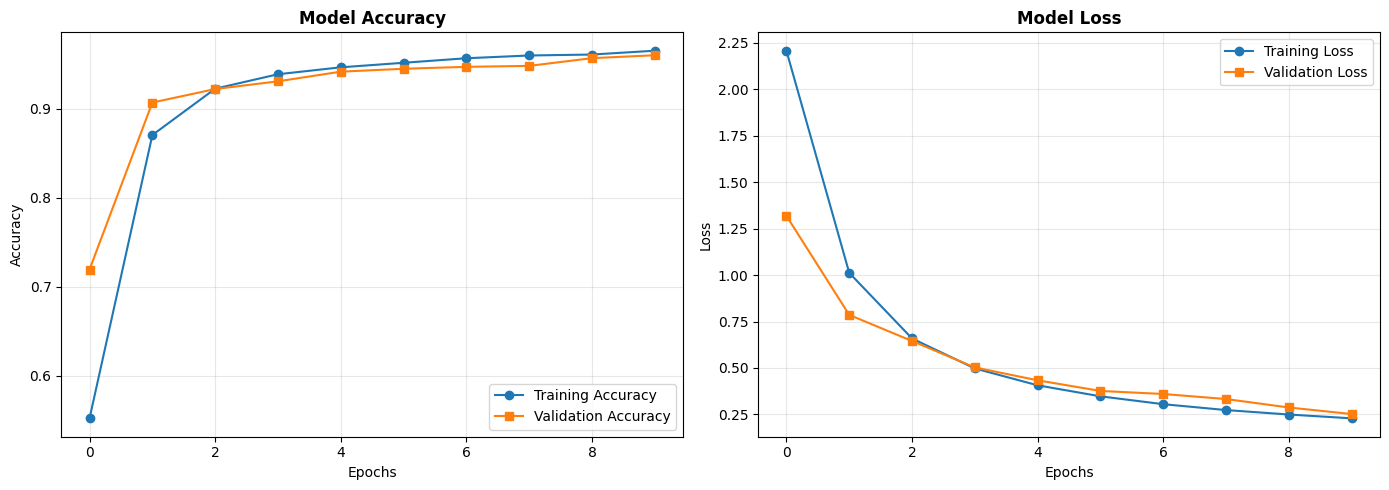

In [40]:
# Plot accuracy and loss in one figure
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax1.set_title('Model Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
ax2.set_title('Model Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import classification_report
 
test_generator = test_datagen.flow_from_directory(
    test_dir, 
    batch_size=32,   
    class_mode='categorical',   
    shuffle=False,  
    target_size=(150, 150)  ) 
 
y_pred = MobileNet_model.predict(test_generator, steps=30)
 
y_pred_classes = np.argmax(y_pred, axis=1)
 
y_true = test_generator.classes
 
print(classification_report(y_true, y_pred_classes))


Found 957 images belonging to 25 classes.
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        13
           2       1.00      0.96      0.98       296
           3       0.98      1.00      0.99       160
           4       1.00      1.00      1.00        21
           5       1.00      1.00      1.00        12
           6       0.79      0.69      0.73        16
           7       0.89      0.85      0.87        20
           8       1.00      1.00      1.00        19
           9       1.00      1.00      1.00        17
          10       1.00      0.97      0.99        39
          11       1.00      1.00      1.00        44
          12       0.95      0.95      0.95        22
          13       1.00      1.00      1.00        19
          14       1.00      1.00      1.00        13
          15       1.00      0.94      0.97        1

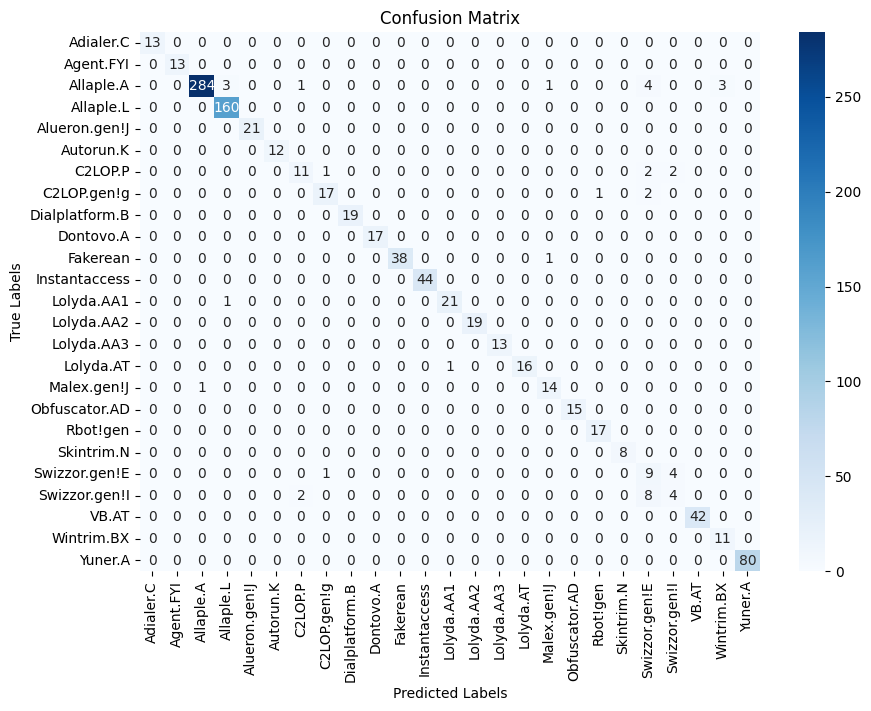

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
 
conf_matrix = confusion_matrix(y_true, y_pred_classes)
 
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_generator.class_indices.keys(), 
            yticklabels=test_generator.class_indices.keys())

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [43]:
 
MobileNet_model.save('/kaggle/working/MobileNet_model.h5')  


# MOBILE NET V2 PREDICTION

In [44]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

In [45]:
 
MobileNet_model= tf.keras.models.load_model('/kaggle/working/MobileNet_model.h5')

In [46]:
class_names = list(train_generator.class_indices.keys())

In [47]:
def predict_image(img_path):
 
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)   
    img_array = np.expand_dims(img_array, axis=0)   
    img_array = img_array / 255.0   
 
    pred = np.argmax(MobileNet_model.predict(img_array), axis=1)
 
    predicted_class = class_names[pred[0]]
    return predicted_class



In [50]:
 
image_path = os.path.join(path,'malimg_dataset/test/Lolyda.AA3/0034e692f76896ec86f3a74eb4ea372f.png')  # Replace with the path to the image you want to classify
predicted_class = predict_image(image_path)
print(f'Predicted Class: {predicted_class}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Class: Lolyda.AA3
